In [174]:
import numpy as np
import matplotlib.pyplot as plt

In [175]:

def setup_tridiagonal_matrix(x, y):

    n = len(x)

    h = np.diff(x)  # Step sizes between data points

    # Initialize the tridiagonal matrix coefficients

    A = np.zeros(n - 2)  # Subdiagonal
    B = np.zeros(n - 2)  # Main diagonal
    C = np.zeros(n - 2)  # Superdiagonal
    D = np.zeros(n - 2)  # Right-hand side vector

    # Populate the tridiagonal matrix coefficients

    for i in range(1, n - 1):

        A[i - 1] = h[i-1]             # Subdiagonal
        B[i - 1] = 2 * (h[i-1] + h[i])       # Main diagonal
        C[i - 1] = h[i]             # Superdiagonal
        D[i - 1] = 6 * ((y[i+1] -y[i])/h[i] - (y[i]-y[i-1])/h[i-1])             # Right-hand side vector

    return A, B, C, D

In [176]:
def thomas_algorithm(a, b, c, d):
    """
    Solve the tridiagonal system using the Thomas algorithm.
    a: sub-diagonal elements (length n-1)
    b: main diagonal elements (length n)
    c: super-diagonal elements (length n-1)
    d: right-hand side (length n)
    Returns: solution vector x of length n
    """
    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x

In [177]:
def evaluate_spline(x_data, y_data, M, x_query):
    """M: second derivatives; M[0]=M[-1]=0 for natural spline"""
    n = len(x_data)
    h = np.diff(x_data) # step sizes
    i = np.searchsorted(x_data, x_query, side='right') - 1
    i = np.clip(i, 0, n - 2) # find interval
    hi = h[i]
    dx_left = x_query - x_data[i] # (x - xᵢ)
    dx_right = x_data[i+1] - x_query # (xᵢ₊₁ - x)
    S = (
        (M[i] / (6*hi)) * dx_right**3 + # Term 1
        (M[i+1] / (6*hi)) * dx_left**3 + # Term 2
        (y_data[i] /hi - M[i] *hi/6) * dx_right + # Term 3
        (y_data[i+1] /hi - M[i+1] *hi/6) * dx_left # Term 4
    )
    return S


In [178]:
def generate_spline(x,y):
    A,B,C,D = setup_tridiagonal_matrix(x,y)
    M_1 = thomas_algorithm(A,B,C,D)
    M = np.zeros(len(y))
    M[1:-1] = M_1
    return M

In [179]:
import numpy as np
def least_squares(x,y):
    assert(len(x) == len(y))
    n = len(x)
    
    sum_x = sum(x)
    sum_y = sum(y)
    sum_x2 = sum([x_i**2 for x_i in x])
    sum_xy = sum([x_i * y_i for x_i,y_i in zip(x,y)])
    
    m = (n * sum_xy - (sum_x * sum_y))/((n * sum_x2) - (sum_x)**2)
    c = (sum_y - (m * sum_x))/n
    return m ,c

In [180]:
def create_vandermonde_matrix(x):
    #Degree 4
    mat = np.zeros((len(x),5))
    print(mat.shape)
    for i in range(len(x)):
        for j in range(5):
            mat[i][j] = x[i] ** j
    return mat

In [181]:
def solve_vandermonde_matrix(x,y):
    vander = create_vandermonde_matrix(x_data)

    A = vander.T @ vander
    B = vander.T @ y
    
    return np.linalg.solve(A,B)

###  GDP Growth Dataset Description

The data stored in the NumPy array `gdp` was obtained from the U.S. Bureau of Economic Analysis (BEA):

https://apps.bea.gov/iTable/?reqid=19&step=3&isuri=1&categories=survey&nipa_table_list=1&Series=Q&select_all_years=1

This dataset represents the **percent change from the preceding period in real Gross Domestic Product (GDP)**.

- **Time Range:** 2010 Q1 → 2023 Q4  
- **Frequency:** Quarterly  
- **x-axis:** Sequential quarters across the time range  
- **y-axis (`gdp`):** Percent change in real GDP from the previous quarter  

In this assingment I will be applying three methods:
1. **Cubic Spline Interpolation:** This method creates a continous piecewise function that passes through every datapoint.For this method I first set up the tridiagonal matrix, and then solve it with the Thomas algorithm.
2. **Polynomial Fit:** This method fits a polynomial of some chosen degree, for this application a degree of 4. In this program I use the vandermonde matrix to create the polynomial fit.
3. **Linear Regression:** This method uses the least squares method to approximate a linear function. The least squares method finds the linear plot that minimizes the sum of residuals.

## **Part A**

### **1. Tridiagonal Matrix & Spline Conditions**

- The tridiagonal matrix defines a matrix of size **\((n - 2) \times (n - 2)\)** curvatures.  

- At each interior knot we must apply the continuity condition that:  
  \[
  S_i(x_i) = y_i, \quad S_i(x_{i+1}) = y_{i+1}
  \]

- The boundary conditions that define a natural spline include, that the curvature at both the first and last point must be equal to 0:  
  \[
  M[0] = 0, \quad M[-1] = 0
  \]

---

### **2. Interpolation Behavior**

- The interpolation is visually smooth and reasonable everywhere, this is expected due to the smoothing and interior conditions that govern a spline. Despite outliers in the dataset the spline should always remain smooth.

---

### **3. Runge’s Phenomenon & Model Tradeoffs**

- Cubic splines minimize the effects of Runge's phenomenon by combining piecewise lower order functions to describe data. Making the function piecewise allows us to not have to create higher order polynomial's that would cause the oscillations present according to Runge's phenomenom.

- When deciding between using a spline v.s. a weighted linear regression model there exists multiple tradeoffs.  

#### **Linear Regression**
1. Easy to miss key features of dataset, since the function output must be linear.  
2. Handles outliers well since it adheres to a strict linear shape.  
3. Computationally more efficent to use model especially when n is large, where n is the number of data points.  
4. Despite enforcing a strict shape, outliers still have effects that propogate to the whole function.  

#### **Cubic Spline**
1. Really good at giving a detailed representation of all features, since the function passes through every data point.  
2. Outliers greatly distort shape of a function locally, since splines must pass through every data point. This makes splines really good for trustworthy datasets.  
3. Computaionally expsensive since segments must be evaluated for all n points.  
4. Despite the loose shape, outliers only effect neighboring points and don't distort shape globally.

    

Text(0.5, 1.0, '% GDP Growth in quarters from 2010 Q1 - 2023 Q4')

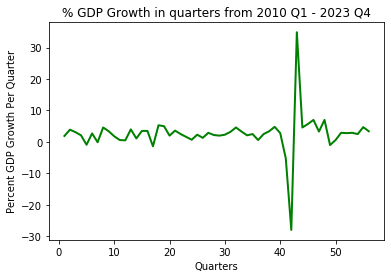

In [182]:
#Part A

M = generate_spline(x_data,gdp)
s = evaluate_spline(x_data,gdp,M,x_data)
plt.plot(x_data, s, color='green', 
     linewidth=2, markersize=12, label="spline")
plt.xlabel("Quarters")
plt.ylabel("Percent GDP Growth Per Quarter")
plt.title("% GDP Growth in quarters from 2010 Q1 - 2023 Q4")

## **Part B**

### **Polynomial Fit V.S. Cubic Spline Interpolation**
- The polynomial fit does a significantly better job at describing an overall trend, that clearly is positive. T
- The cubic spline does a worse job at describing the overall trend since the spline must pass through every point. However, it also clearly shows where positve and negative trends are specifically throughout the quarters, which is not clear through the polynomial fit.
- Polynomial fitting is an approximation method which means we're fitting the data to the degree of polynomial. While cubic spline is an interpolation method where we're fitting the model to the data. This difference between approximation and interpolation leads to the conclusions about tradeoffs reached in the above points.

### **Using a least squares linear model**
- The slope of the linear model is 0.0269 %GDP growth per quarter. 
- Due to the fact that the polynomial fit created a roughly linear shape, I would say using a least squares method makes sense here. 
- We need to assume that the underlying function is linear for this to be a useful model for the data. Rarely real world data adheres to this assumption, so the model does a good overall job at representing the data, however fails to pick up any local features.
- Specifically In this example we choose to exclude the data from COVID in our least squares method. With such a data points the linear model would completely overlook there changes and instead propogate the changes to the whole model. This approximation distorts the graph and overlooks such dramatic events.

(56, 5)
(52,)
0.015418391775806234


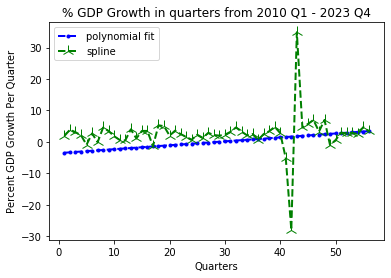

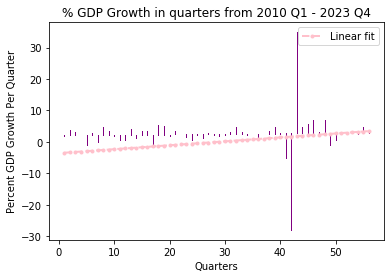

In [183]:
#Part B
x_scaled = (x_data - np.mean(x_data)) / np.std(x_data)
a = solve_vandermonde_matrix(x_scaled,gdp)
y = [np.sum(a * x) for x in x_scaled]

plt.plot(x_data, y, color='blue', marker='o', linestyle='dashed',
     linewidth=2, markersize=3, label="polynomial fit")
plt.plot(x_data, s, color='green', marker='2', linestyle='dashed',
     linewidth=2, markersize=12, label="spline")
plt.xlabel("Quarters")
plt.ylabel("Percent GDP Growth Per Quarter")
plt.title("% GDP Growth in quarters from 2010 Q1 - 2023 Q4")
plt.legend()

##41:45 are the indicies of the COVID quarters
x_filtered = np.delete(x_data, np.s_[41:45])
gdp_filtered = np.delete(gdp,np.s_[41:45])
print(x_filtered.shape)

m,c = least_squares(x_filtered,gdp_filtered)
print(m)
lin_y = (m*x_data) + c
plt.figure()
for x, y_actual, y_pred in zip(x_data, gdp, lin_y):
    plt.plot([x, x], [y_actual, y_pred], color='purple', linewidth=1)


plt.plot(x_data, y, color='pink', marker='o', linestyle='dashed',
     linewidth=2, markersize=3, label="Linear fit")
plt.xlabel("Quarters")
plt.ylabel("Percent GDP Growth Per Quarter")
plt.title("% GDP Growth in quarters from 2010 Q1 - 2023 Q4")
plt.legend()

## **Part C**

### **Cubic Spline V.S. Polynomial Fitting, For a Policymaker**

- Cubic Spline does a significantly better job at interpolating between two points. Cubic splines pass through every point of the dataset, highlighting outliers. This can be useful since these outliers can represent effects of polcy, e.g. Tarriffs, Iran war, COVID-19, etc. This makes cubic spline interpolation a significantly method for the uses of the policymaker.  

- On top of this polynomial fits tend to propogate error from outliers to changes throughout the whole function. In real world data such as GDP, representing such noisy and unpredictable data tends to not be well represented just by a polynomial.  

---

### **Time Complexity Considerations**

- **Cubic Spline Interpolation:** \(O(n)\)  
- **Polynomial Fitting:** \(O(n^3)\)  
- **Linear Least Squares:** \(O(n)\)  

- Considering the time complexity of each method, I would use Cubic Spline Interpolation and Linear Least Squares for my analysis.  

- Linear least squares would be used to analyze the overall trend, and cubic spline interpolation would be used for interpolation and feature analysis.

## **Conclusion**

In this project we used a linear least squares method, polynomial fit and cubic spline interpolation. We used these methods on a dataset from the Bureau of Economic Analysis that describes the percent GDP growth per quarter from 2010 Q1 to 2023 Q4. The linear least squares method was a good representation of the overall trend of the economy, but failed to describe the outliers such as COVID. Cubic Spline interpolation fixed this problem by clearly describing local trends between quarters, but not giving a great description of the overall trend of the economy. Finally, I think for this dataset the polynomial fit wasn't particular useful since it has the largest time complexity and approximates to a linear like function. The main thing I learned from this project was that their is no model that is "better". Each model serves their own purpose and will allow you different insights into the data then others, given the dataset/.